# Fractal Interpolation Function (Deterministic Algorithm)

We are given interpolation data

$$
\{(x_n,y_n)\}_{n=0}^{N}
$$

with

$$
x_0 < x_1 < \cdots < x_N
$$

and scaling factors

$$
\{\alpha_n\}_{n=1}^{N}
$$

such that

$$
|\alpha_n| < 1
$$

We define affine maps

$$
w_n(x,y)
=
\begin{pmatrix}
L_n(x) \\
F_n(x,y)
\end{pmatrix}
$$

where

$$
L_n(x)=a_nx+b_n
$$

and

$$
F_n(x,y)=\alpha_n y+c_nx+d_n
$$

The coefficients are determined by the join-up conditions:

$$
L_n(x_0)=x_{n-1},
\qquad
L_n(x_N)=x_n
$$

and

$$
F_n(x_0,y_0)=y_{n-1},
\qquad
F_n(x_N,y_N)=y_n
$$

Hence,

$$
a_n=\frac{x_n-x_{n-1}}{x_N-x_0}
$$

$$
b_n=\frac{x_Nx_{n-1}-x_0x_n}{x_N-x_0}
$$

$$
c_n=
\frac{
y_n-y_{n-1}
-\alpha_n(y_N-y_0)
}{
x_N-x_0
}
$$

$$
d_n=
\frac{
x_Ny_{n-1}
-x_0y_n
-\alpha_n(x_Ny_0-x_0y_N)
}{
x_N-x_0
}
$$

The deterministic algorithm repeatedly applies all maps to the current approximation of the attractor.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1 : Input the interpolation data

We specify

$$
(x_0,y_0), (x_1,y_1), \dots, (x_N,y_N)
$$

and the vertical scaling factors

$$
\alpha_1,\alpha_2,\dots,\alpha_N
$$

In [ ]:
# Interpolation points

x = np.array([0, 1, 2, 3, 4], dtype=float)

y = np.array([0, 2, 1, 3, 0], dtype=float)

# Vertical scaling factors

alpha = np.array([0.3, -0.4, 0.2, 0.5], dtype=float)

# Number of maps

N = len(x) - 1

# Step 2 : Define endpoints

We denote

$$
I=[x_0,x_N]
$$

The endpoints are needed in all coefficient formulas.

In [ ]:
x0 = x[0]
xN = x[-1]

y0 = y[0]
yN = y[-1]

# Step 3 : Compute the coefficients

For each affine map

$$
w_n(x,y)
=
\begin{pmatrix}
a_nx+b_n \\
\alpha_n y+c_nx+d_n
\end{pmatrix}
$$

we compute

$$
a_n=\frac{x_n-x_{n-1}}{x_N-x_0}
$$

$$
b_n=\frac{x_Nx_{n-1}-x_0x_n}{x_N-x_0}
$$

$$
c_n=
\frac{
y_n-y_{n-1}
-\alpha_n(y_N-y_0)
}{
x_N-x_0
}
$$

$$
d_n=
\frac{
x_Ny_{n-1}
-x_0y_n
-\alpha_n(x_Ny_0-x_0y_N)
}{
x_N-x_0
}
$$

In [ ]:
a = np.zeros(N)
b = np.zeros(N)

c = np.zeros(N)
d = np.zeros(N)

for n in range(N):

    xn_minus_1 = x[n]
    xn = x[n+1]

    yn_minus_1 = y[n]
    yn = y[n+1]

    alpha_n = alpha[n]

    # Compute a_n

    a[n] = (xn - xn_minus_1) / (xN - x0)

    # Compute b_n

    b[n] = (xN*xn_minus_1 - x0*xn) / ( xN - x0 )

    # Compute c_n

    c[n] = (yn - yn_minus_1 - alpha_n*(yN - y0)) / (xN - x0)

    # Compute d_n

    d[n] = (xN*yn_minus_1 - x0*yn - alpha_n*(xN*y0 - x0*yN)) / (xN - x0)

# Step 4 : Define the affine maps

Each map is

$$
w_n(x,y)
=
\begin{pmatrix}
a_nx+b_n \\
\alpha_n y+c_nx+d_n
\end{pmatrix}
$$

In [ ]:
def w(n, point):

    x_current, y_current = point

    new_x = (a[n]*x_current + b[n])

    new_y = (alpha[n]*y_current + c[n]*x_current + d[n])

    return np.array([new_x, new_y])

# Step 5 : Initial approximation

The deterministic algorithm begins with an initial set.

Usually the interpolation polygon is chosen:

$$
\{(x_n,y_n)\}_{n=0}^{N}
$$

In [ ]:
current_points = np.column_stack((x, y))

# Step 6 : Deterministic Iteration

At every iteration we apply **all affine maps** to the current set.

Mathematically,

$$
A_{k+1}
=
\bigcup_{n=1}^{N}
w_n(A_k)
$$

where \(A_k\) is the current approximation.

As the number of iterations increases,

$$
A_k \to G(f)
$$

where \(G(f)\) is the graph of the fractal interpolation function.

In [ ]:
num_iterations = 8

for iteration in range(num_iterations):

    new_points = []

    # Apply every affine map
    # to every current point

    for n in range(N):

        for point in current_points:

            transformed_point = w(n, point)

            new_points.append(transformed_point)

    current_points = np.array(new_points)

    print(
        f"Iteration {iteration+1} : " f"{len(current_points)} points"
    )

Iteration 1 : 20 points
Iteration 2 : 80 points
Iteration 3 : 320 points
Iteration 4 : 1280 points
Iteration 5 : 5120 points
Iteration 6 : 20480 points
Iteration 7 : 81920 points
Iteration 8 : 327680 points


# Step 7 : Plot the attractor

The generated point cloud approximates the graph of the fractal interpolation function.

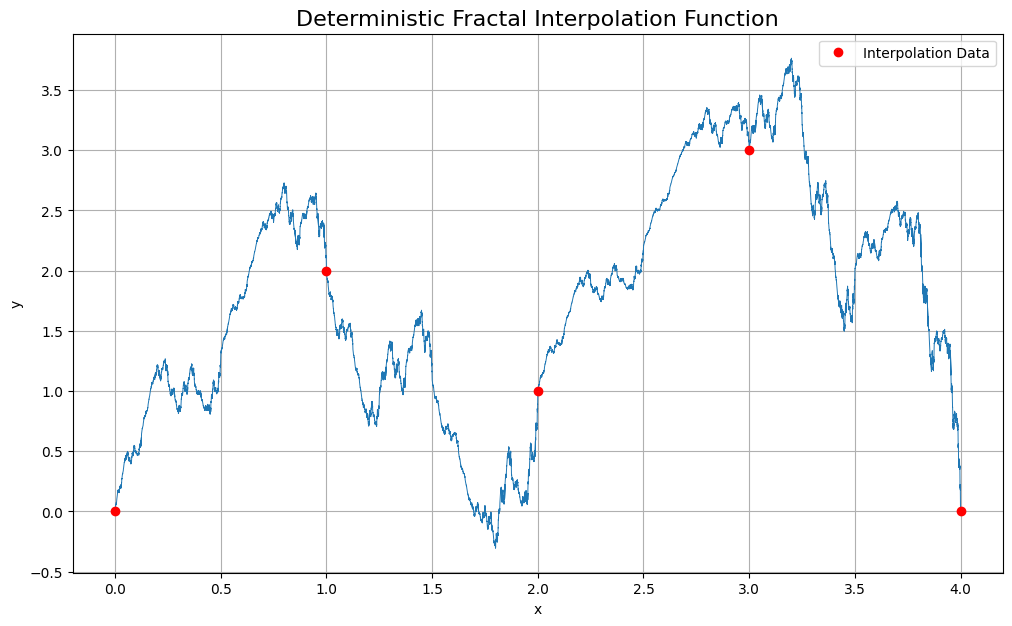

In [ ]:
# Sort points for cleaner plotting

sorted_indices = np.argsort(current_points[:,0])

sorted_points = current_points[sorted_indices]

plt.figure(figsize=(12,7))

# Plot fractal curve

plt.plot(
    sorted_points[:,0],
    sorted_points[:,1],
    linewidth=0.7
)

# Plot interpolation points

plt.plot(
    x,
    y,
    'ro',
    markersize=6,
    label='Interpolation Data'
)

plt.title(
    "Deterministic Fractal Interpolation Function",
    fontsize=16
)

plt.xlabel("x")

plt.ylabel("y")

plt.grid(True)

plt.legend()

plt.show()

# Difference Between Deterministic and Random Iteration Algorithms

## Deterministic Algorithm

The deterministic algorithm computes

$$
A_{k+1}
=
\bigcup_{n=1}^{N} w_n(A_k)
$$

by applying every map to every point.

Advantages:
- Direct geometric interpretation
- Easy to understand mathematically
- Shows self-affine structure clearly

Disadvantages:
- Number of points grows exponentially
- Computationally expensive

---

## Random Iteration Algorithm (Chaos Game)

The random algorithm computes

$$
X_{k+1}=w_{i_k}(X_k)
$$

where \(i_k\) is randomly selected.

Advantages:
- Extremely fast
- Memory efficient
- Produces high-resolution attractors quickly

Disadvantages:
- More probabilistic in nature
- Harder to visualize mathematically at first